In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Định nghĩa cùng một bảng màu để đảm bảo tính nhất quán
COLOR_MAP = {
    "Tay ga": "#3498db",
    "Xe số": "#2ecc71",
    "Xe thể thao": "#e74c3c",
    "Xe 50cc": "#f1c40f",
    "Khác": "#95a5a6"
}

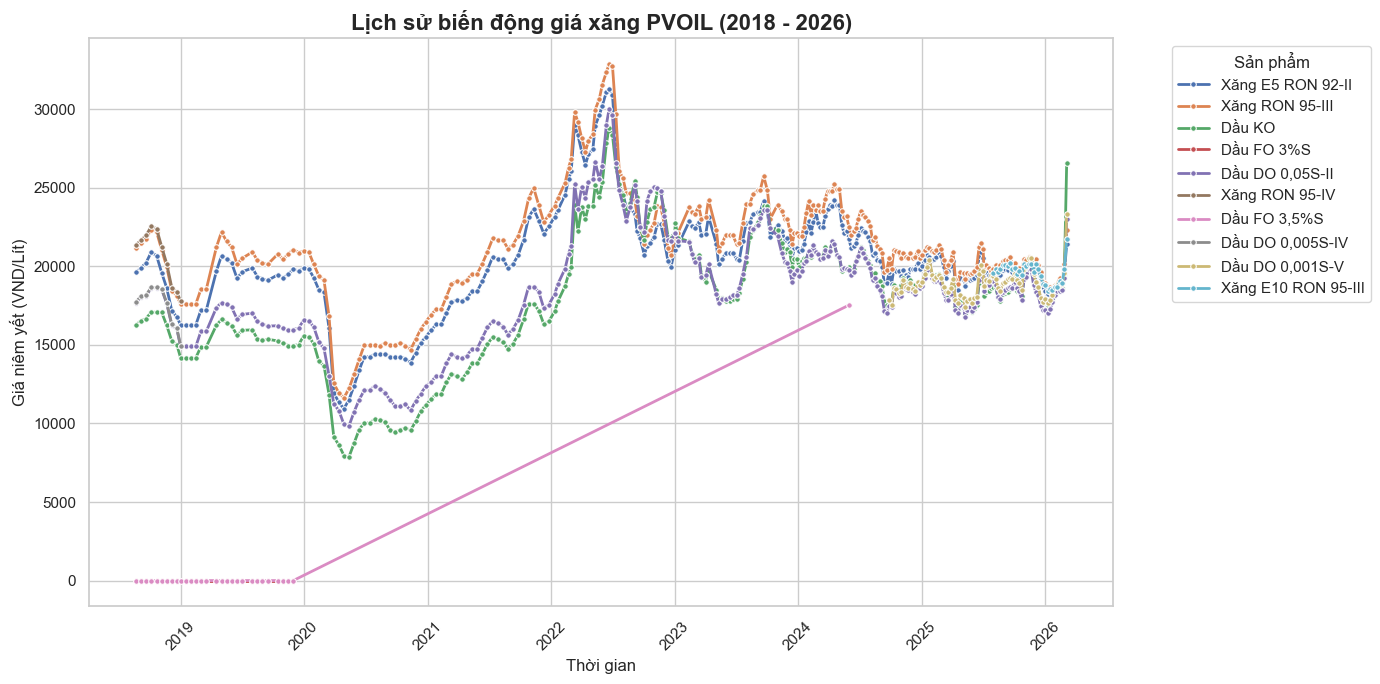

In [2]:

def report_fuel_price_trends(json_path="pvoil_prices.json"):
    # 1. Đọc dữ liệu JSON
    if not os.path.exists(json_path):
        print(f"Không tìm thấy file {json_path}")
        return
        
    with open(json_path, 'r', encoding='utf-8') as f:
        price_data = json.load(f)

    # 2. Chuyển đổi JSON sang DataFrame
    price_records = []
    for date_str, info in price_data.items():
        # Lấy danh sách xăng trong ngày đó
        fuels = info.get('fuels', [])
        for item in fuels:
            price_records.append({
                "Ngày": date_str,
                "Loại xăng": item['fuel_type'],
                "Giá (VND)": item['price_vnd']
            })

    df = pd.DataFrame(price_records)
    
    # Chuyển cột Ngày sang định dạng datetime và sắp xếp
    df['Ngày'] = pd.to_datetime(df['Ngày'], format='%d-%m-%Y')
    df = df.sort_values('Ngày')

    # 3. Vẽ biểu đồ
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 7))

    # Vẽ đường line cho từng loại xăng
    sns.lineplot(data=df, x='Ngày', y='Giá (VND)', hue='Loại xăng', linewidth=2, marker='o', markersize=4)

    # Định dạng biểu đồ
    plt.title("Lịch sử biến động giá xăng PVOIL (2018 - 2026)", fontsize=16, fontweight='bold')
    plt.xlabel("Thời gian", fontsize=12)
    plt.ylabel("Giá niêm yết (VND/Lít)", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title="Sản phẩm", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    report_fuel_price_trends()

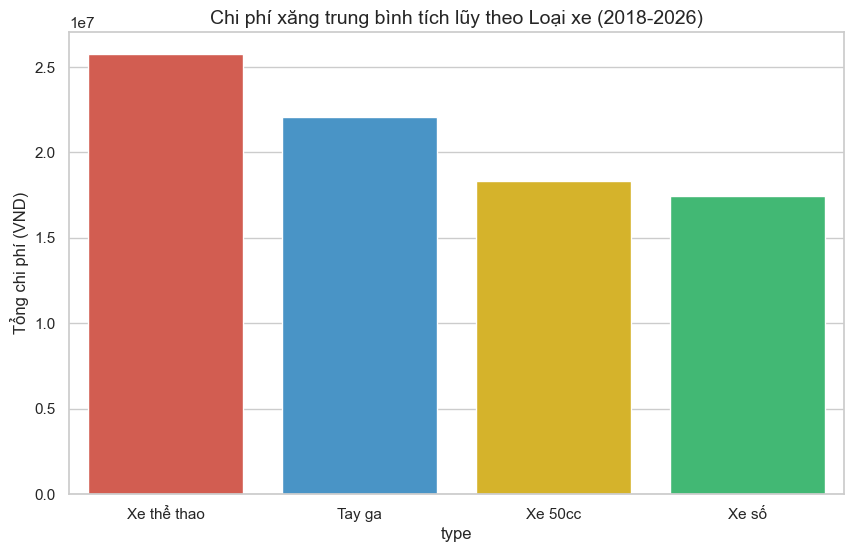

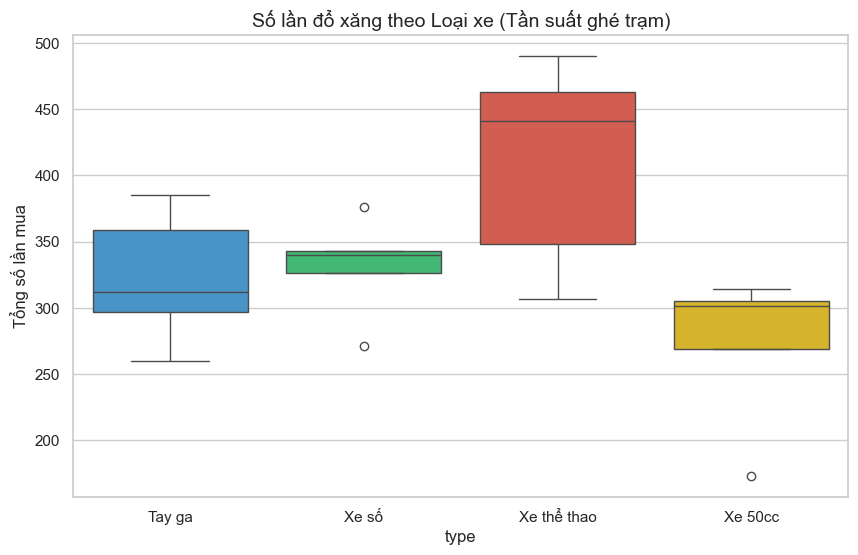

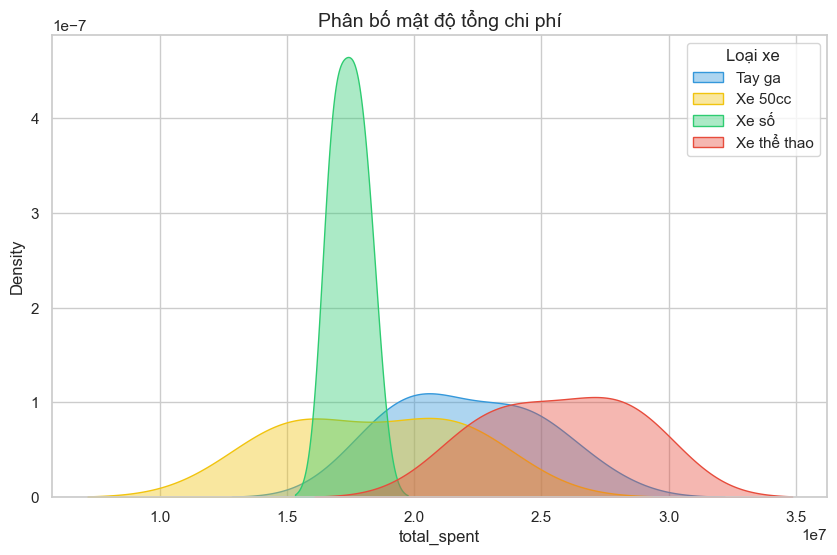

In [3]:
def visualize_by_vehicle_type(
    json_path="/Users/my/DCA-on-filling-your-motorbike/03. fuel_purchase_history.json", 
    csv_path="/Users/my/DCA-on-filling-your-motorbike/bike_fuel_rate.csv"
):
    if not os.path.exists(csv_path) or not os.path.exists(json_path):
        print("Error: Required files not found.")
        return
        
    # 1. Process Bike Metadata
    bikes_df = pd.read_csv(csv_path)
    bikes_df.columns = bikes_df.columns.str.strip()
    bikes_df['full_name'] = (bikes_df['Hãng xe'].str.strip() + " " + bikes_df['Dòng xe'].str.strip())
    type_map = dict(zip(bikes_df['full_name'], bikes_df['Loại xe'].str.strip()))

    # 2. Load and Parse Simulation Data
    with open(json_path, 'r', encoding='utf-8') as f:
        sim_data = json.load(f)
    
    summary_list = []
    for bike_name, info in sim_data.items():
        v_type = type_map.get(bike_name.strip(), "Khác")
        
        # Accessing nested 'summary' key based on your snippet
        summary = info.get('summary', {})
        total_spent = summary.get('total_spent_vnd', 0)
        total_purchases = summary.get('total_purchases', 0)
        
        summary_list.append({
            "bike_name": bike_name.strip(),
            "total_spent": total_spent,
            "total_purchases": total_purchases,
            "type": v_type,
            "avg_bill": total_spent / total_purchases if total_purchases > 0 else 0
        })
    
    summary_df = pd.DataFrame(summary_list)
    sns.set_theme(style="whitegrid")

    # --- CHART 1: TOTAL ACCUMULATED COST ---
    plt.figure(figsize=(10, 6))
    avg_by_type = summary_df.groupby('type')['total_spent'].mean().sort_values(ascending=False).reset_index()
    sns.barplot(data=avg_by_type, x='type', y='total_spent', hue='type', palette=COLOR_MAP, legend=False)
    plt.title("Chi phí xăng trung bình tích lũy theo Loại xe (2018-2026)", fontsize=14)
    plt.ylabel("Tổng chi phí (VND)")
    plt.show()

    # --- CHART 2: REFUELING FREQUENCY ---
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=summary_df, x='type', y='total_purchases', hue='type', palette=COLOR_MAP, legend=False)
    plt.title("Số lần đổ xăng theo Loại xe (Tần suất ghé trạm)", fontsize=14)
    plt.ylabel("Tổng số lần mua")
    plt.show()

    # --- CHART 3: DENSITY DISTRIBUTION ---
    plt.figure(figsize=(10, 6))
    for v_type in sorted(summary_df['type'].unique()):
        subset = summary_df[summary_df['type'] == v_type]
        sns.kdeplot(subset['total_spent'], label=v_type, fill=True, color=COLOR_MAP.get(v_type, "#95a5a6"), alpha=0.4)
    plt.title("Phân bố mật độ tổng chi phí", fontsize=14)
    plt.legend(title="Loại xe")
    plt.show()

if __name__ == "__main__":
    visualize_by_vehicle_type()

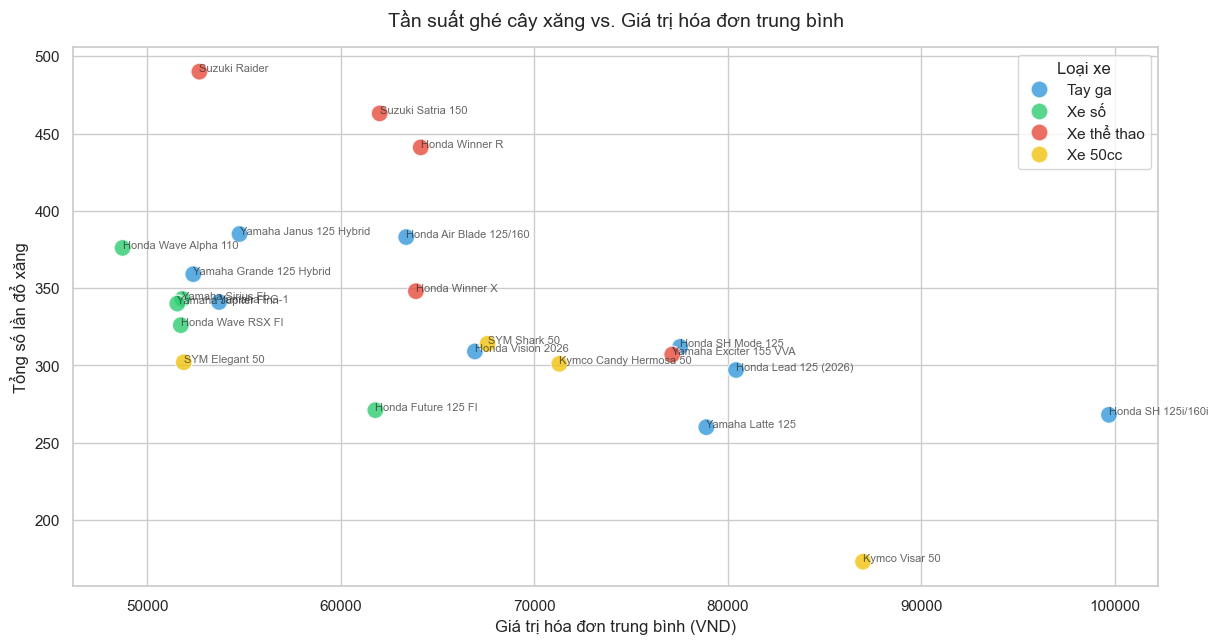

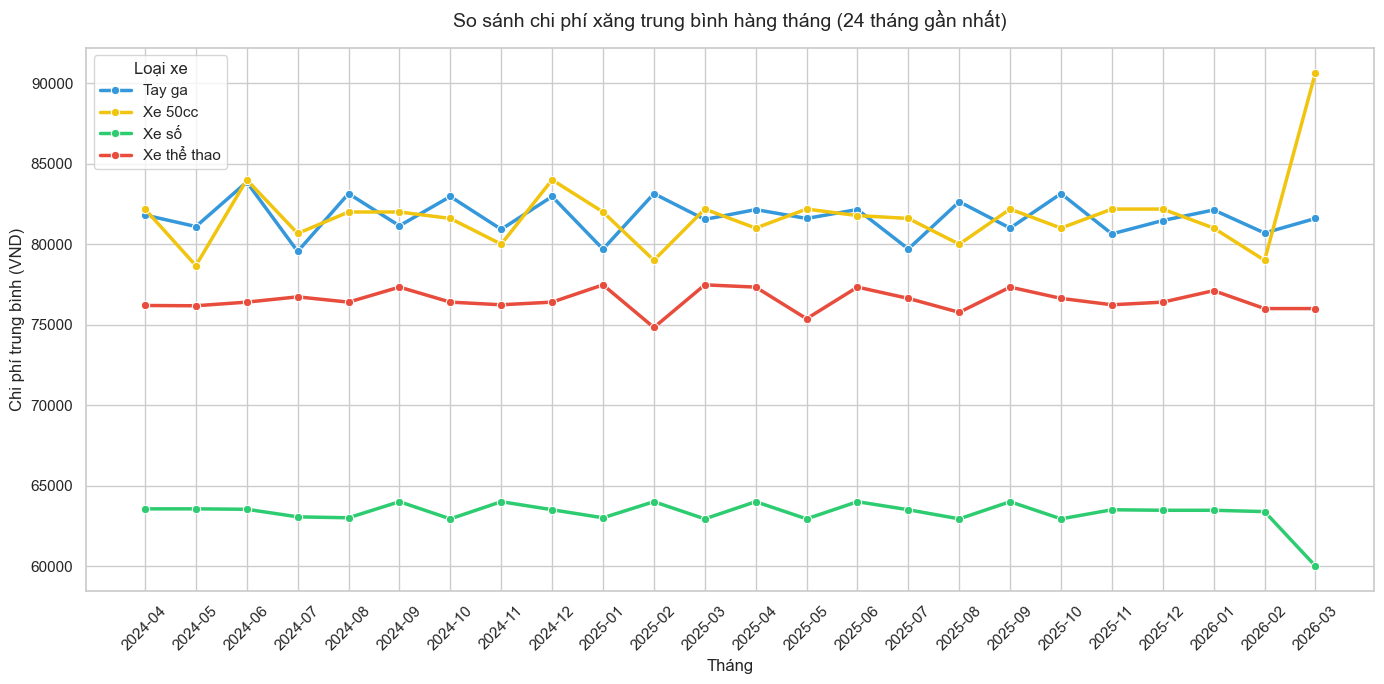

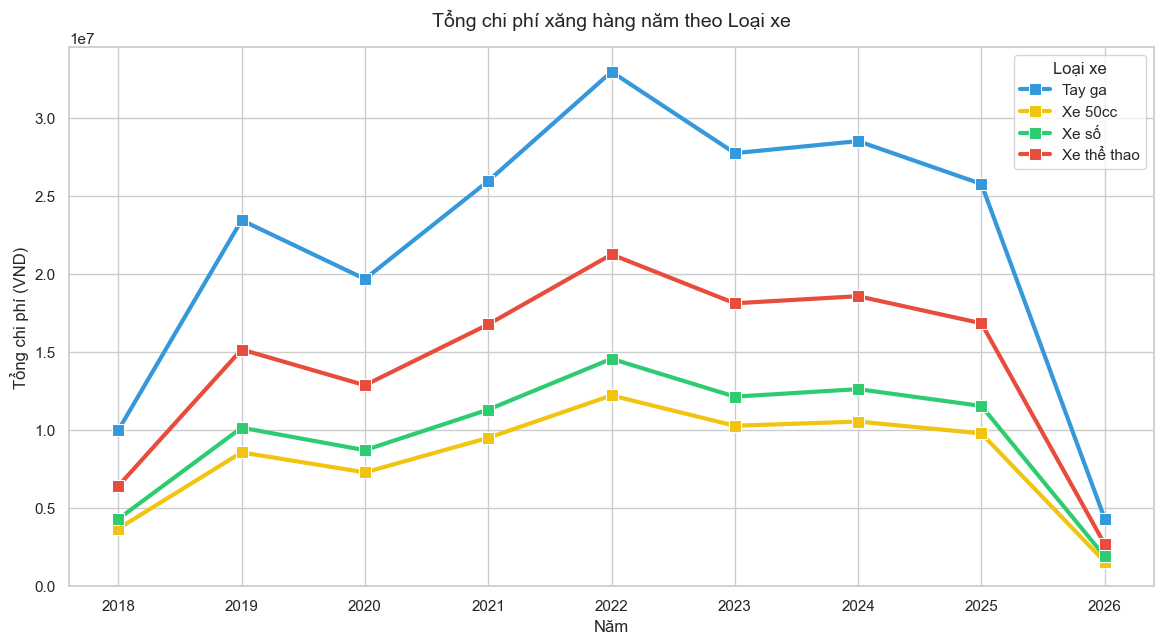

In [4]:

def visualize_comparison(
    json_path="/Users/my/DCA-on-filling-your-motorbike/03. fuel_purchase_history.json", 
    csv_path="/Users/my/DCA-on-filling-your-motorbike/bike_fuel_rate.csv"
):
    if not os.path.exists(csv_path):
        print(f"Lỗi: Không tìm thấy file CSV tại {csv_path}")
        return
    if not os.path.exists(json_path):
        print(f"Lỗi: Không tìm thấy file JSON tại {json_path}")
        return
    
    # 1. Process Bike Metadata
    bikes_df = pd.read_csv(csv_path)
    bikes_df.columns = bikes_df.columns.str.strip()
    bikes_df['full_name'] = (bikes_df['Hãng xe'].str.strip() + " " + bikes_df['Dòng xe'].str.strip())
    type_map = dict(zip(bikes_df['full_name'], bikes_df['Loại xe'].str.strip()))

    # 2. Load Simulation Data
    with open(json_path, 'r', encoding='utf-8') as f:
        sim_data = json.load(f)
    
    history_records = []
    summary_records = []

    # 3. Parse Data using the correct nested JSON keys
    for bike_name, info in sim_data.items():
        v_type = type_map.get(bike_name.strip(), "Khác")
        
        # Extract from the 'summary' nested dictionary
        summary = info.get('summary', {})
        total_spent = summary.get('total_spent_vnd', 0)
        total_purchases = summary.get('total_purchases', 0)
        avg_bill = total_spent / total_purchases if total_purchases > 0 else 0
        
        summary_records.append({
            "bike_name": bike_name.strip(),
            "total_spent": total_spent,
            "total_purchases": total_purchases,
            "avg_bill": avg_bill,
            "type": v_type
        })
        
        # Extract from the 'history' list
        for record in info.get('history', []):
            history_records.append({
                "date": record['date'],
                "cost_vnd": record['cost_vnd'],
                "type": v_type
            })

    # 4. Dataframe Formatting
    df = pd.DataFrame(history_records)
    summary_df = pd.DataFrame(summary_records)
    
    # Convert dates for time-series plotting
    df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
    df['month_year'] = df['date'].dt.to_period('M')
    df['year'] = df['date'].dt.year

    sns.set_theme(style="whitegrid")

    # --- BIỂU ĐỒ 1: TẦN SUẤT vs GIÁ TRỊ BILL (SCATTER) ---
    plt.figure(figsize=(14, 7))
    sns.scatterplot(
        data=summary_df, 
        x='avg_bill', 
        y='total_purchases', 
        hue='type', 
        palette=COLOR_MAP, 
        s=150, 
        alpha=0.8
    )
    
    # Add bike name annotations to the scatter plot
    for i, row in summary_df.iterrows():
        plt.text(row['avg_bill'], row['total_purchases'], row['bike_name'], fontsize=8, alpha=0.7)
        
    plt.title("Tần suất ghé cây xăng vs. Giá trị hóa đơn trung bình", fontsize=14, pad=15)
    plt.xlabel("Giá trị hóa đơn trung bình (VND)")
    plt.ylabel("Tổng số lần đổ xăng")
    plt.legend(title="Loại xe")
    plt.show()

    # --- BIỂU ĐỒ 2: BILL MỖI THÁNG - LINE CHART (Last 24 Months) ---
    monthly_type_df = df.groupby(['type', 'month_year'])['cost_vnd'].mean().reset_index()
    monthly_type_df['month_year_str'] = monthly_type_df['month_year'].astype(str)
    
    plt.figure(figsize=(14, 7))
    recent_months = sorted(monthly_type_df['month_year_str'].unique())[-24:]
    plot_df = monthly_type_df[monthly_type_df['month_year_str'].isin(recent_months)]
    
    sns.lineplot(
        data=plot_df, 
        x='month_year_str', 
        y='cost_vnd', 
        hue='type', 
        palette=COLOR_MAP, 
        marker='o', 
        linewidth=2.5
    )
    plt.title("So sánh chi phí xăng trung bình hàng tháng (24 tháng gần nhất)", fontsize=14, pad=15)
    plt.xlabel("Tháng")
    plt.ylabel("Chi phí trung bình (VND)")
    plt.xticks(rotation=45)
    plt.legend(title="Loại xe")
    plt.tight_layout()
    plt.show()

    # --- BIỂU ĐỒ 3: BILL MỖI NĂM - LINE CHART ---
    yearly_type_df = df.groupby(['type', 'year'])['cost_vnd'].sum().reset_index()
    
    plt.figure(figsize=(14, 7))
    sns.lineplot(
        data=yearly_type_df, 
        x='year', 
        y='cost_vnd', 
        hue='type', 
        palette=COLOR_MAP, 
        marker='s', 
        markersize=8, 
        linewidth=3
    )
    plt.title("Tổng chi phí xăng hàng năm theo Loại xe", fontsize=14, pad=15)
    plt.xlabel("Năm")
    plt.ylabel("Tổng chi phí (VND)")
    plt.legend(title="Loại xe")
    plt.show()

if __name__ == "__main__":
    visualize_comparison()